# AI-Generated vs. Human-Written Text Classifier (Keras Tokenizer + BiLSTM)

Same style as your reference script: `Tokenizer` + `pad_sequences`, a `create_model()` function, `model.fit()` with a validation set, saved `.keras` model + pickled tokenizer, and a side-by-side accuracy/loss plot.

**Data:** upload `AI-Generated-Essays-Dataset.csv` and `CNN_DailyMail.csv` when prompted (or point `DATASET_DIR` at your Google Drive folder if you'd rather mount Drive).

> ⚠️ Only 85 confirmed AI-generated rows exist across both files vs. thousands of human rows — severe class imbalance. `class_weight` is used in `model.fit()` to compensate; treat results as a baseline.

**Runtime:** `Runtime > Change runtime type > T4 GPU`.


In [6]:
import os
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout


## Upload the datasets
Select **both** CSV files when prompted.

In [7]:
import pandas as pd

# Load your datasets
ai_df = pd.read_csv(r"C:\Users\Sathy\Downloads\AI-Generated-Essays-Dataset.csv")
human_df = pd.read_csv(r"C:\Users\Sathy\Downloads\CNN_DailyMail.csv")

print(ai_df.head())
print(human_df.head())

                                                text  generated
0  Machine learning, a subset of artificial intel...          1
1  A decision tree, a prominent machine learning ...          1
2  Education, a cornerstone of societal progress,...          1
3  Computers, the backbone of modern technology, ...          1
4  Chess, a timeless game of strategy and intelle...          1
                                               Title  \
0  John and . Audrey Cook were discovered alongsi...   
1  NEW: Libya can serve as example of cooperation...   
2  Very Reverend Robert Waddington sexually abuse...   
3  Monday night's episode showed Buddy Valastro t...   
4  People asked to turn out lights for hour betwe...   

                                                Text  
0  By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 ...  
1  UNITED NATIONS (CNN) -- A rare meeting of U.N....  
2  Cover-up: Former Archbishop Lord Hope allowed ...  
3  By . Kristie Lau . PUBLISHED: . 10:48 EST, 14 ...  
4  '

In [8]:
AI_ESSAYS_PATH = "AI-Generated-Essays-Dataset.csv"
NEWS_PATH = "CNN_DailyMail.csv"

VOCAB_SIZE = 10000
MAX_LENGTH = 200
EMBEDDING_DIM = 128
OOV_TOKEN = "<OOV>"

EPOCHS = 10
BATCH_SIZE = 32
SEED = 42


# ======================================================
# Load Dataset
# ======================================================

In [9]:
print("Loading dataset...")

ai_df = pd.read_csv(AI_ESSAYS_PATH)
news_df = pd.read_csv(NEWS_PATH)

print("AI-Generated-Essays-Dataset head:\n", ai_df.head())
print("Available columns (essays):", ai_df.columns.tolist())
print("Available columns (news):", news_df.columns.tolist())

# ======================================================
# Build a single text/label dataset
#   label = 1 -> AI-generated
#   label = 0 -> human-written
# ======================================================

def clean_text(t):
    t = str(t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

ai_pos = ai_df[ai_df["generated"] == 1][["text"]].copy()
ai_pos["label"] = 1

ai_neg = ai_df[ai_df["generated"] == 0][["text"]].copy()
ai_neg["label"] = 0

news_neg = news_df[["Text"]].rename(columns={"Text": "text"}).copy()
news_neg["label"] = 0

n_ai = len(ai_pos)
target_human = min(len(ai_neg) + len(news_neg), n_ai * 10)  # cap majority class at 10x minority

human_pool = pd.concat([ai_neg, news_neg], ignore_index=True)
human_sample = human_pool.sample(n=min(target_human, len(human_pool)), random_state=SEED)

df = pd.concat([ai_pos, human_sample], ignore_index=True)
df["text"] = df["text"].apply(clean_text)
df = df[df["text"].str.len() > 20].reset_index(drop=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Dataset head:\n", df.head())
print("Label counts:\n", df["label"].value_counts())

texts = df["text"].astype(str)
labels = df["label"].values

print("Total Samples :", len(df))


Loading dataset...
AI-Generated-Essays-Dataset head:
                                                 text  generated
0  Machine learning, a subset of artificial intel...          1
1  A decision tree, a prominent machine learning ...          1
2  Education, a cornerstone of societal progress,...          1
3  Computers, the backbone of modern technology, ...          1
4  Chess, a timeless game of strategy and intelle...          1
Available columns (essays): ['text', 'generated']
Available columns (news): ['Title', 'Text']
Dataset head:
                                                 text  label
0  While most Americans celebrate Thanksgiving by...      0
1  The Nissan Xterra, a rugged and versatile SUV,...      1
2  Washington (CNN) -- First lady Michelle Obama ...      0
3  (CNN)For a guy whose most famous character who...      0
4  (EW.com) -- After a day of giving thanks, eati...      0
Label counts:
 label
0    850
1     85
Name: count, dtype: int64
Total Samples : 935


# ======================================================
# Split Dataset
# ======================================================

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))


Training Samples : 748
Testing Samples  : 187


# ======================================================
# Tokenization
# ======================================================

In [11]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)


# ======================================================
# Padding
# ======================================================

In [12]:
X_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("Padding Completed")


Padding Completed


# ======================================================
# Class Weights (dataset is heavily imbalanced: far more human than AI text)
# ======================================================

In [13]:
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)
class_weight = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print("Class weights [human, AI]:", class_weight)


Class weights [human, AI]: {0: 0.55, 1: 5.5}


# ======================================================
# Create Model
# ======================================================

In [14]:
def create_model(vocab_size, max_length):
    model = Sequential([
        Embedding(vocab_size, EMBEDDING_DIM, input_length=max_length),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Creating Model...")

model = create_model(
    vocab_size=VOCAB_SIZE,
    max_length=MAX_LENGTH
)

model.summary()


Creating Model...


C:\Users\Sathy\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# ======================================================
# Train Model
# ======================================================

In [15]:
print("Training Started...")

history = model.fit(

    X_train_pad,
    y_train,

    validation_data=(
        X_test_pad,
        y_test
    ),

    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    verbose=1

)

print("Training Completed!")


Training Started...
Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.8557 - loss: 0.6370 - val_accuracy: 0.9358 - val_loss: 0.4113
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.9536 - loss: 0.3680 - val_accuracy: 0.9947 - val_loss: 0.0638
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - accuracy: 0.9892 - loss: 0.1804 - val_accuracy: 0.9840 - val_loss: 0.0712
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.9865 - loss: 0.0347 - val_accuracy: 0.9626 - val_loss: 0.0561
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.9827 - loss: 0.0330 - val_accuracy: 0.9679 - val_loss: 0.1138
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.9800 - loss: 0.1497 - val_accuracy: 0.9893 - val_loss: 0.0509
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.9901 - loss: 0.0216 - val_accuracy: 0.9840 - val_loss: 0.0402
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 107ms/step - accuracy: 0.9908 - loss: 0.02

# ======================================================
# Save Model
# ======================================================

In [16]:
os.makedirs("saved_model", exist_ok=True)

model.save("saved_model/model.keras")

print("Model Saved")


Model Saved


# ======================================================
# Save Tokenizer
# ======================================================

In [17]:
with open("saved_model/tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer Saved")


Tokenizer Saved


# ======================================================
# Evaluate
# ======================================================

In [18]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print("\n============================")
print("Test Accuracy :", round(accuracy * 100, 2), "%")
print("Test Loss     :", round(loss, 4))
print("============================")



Test Accuracy : 99.47 %
Test Loss     : 0.024


# ======================================================
# Classification Report (accuracy alone is misleading on imbalanced data)
# ======================================================

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()

print(classification_report(y_test, y_pred, target_names=["Human", "AI"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step
              precision    recall  f1-score   support

       Human       1.00      0.99      1.00       170
          AI       0.94      1.00      0.97        17

    accuracy                           0.99       187
   macro avg       0.97      1.00      0.98       187
weighted avg       0.99      0.99      0.99       187

Confusion Matrix:
 [[169   1]
 [  0  17]]


# ======================================================
# Plot Accuracy Graph
# ======================================================

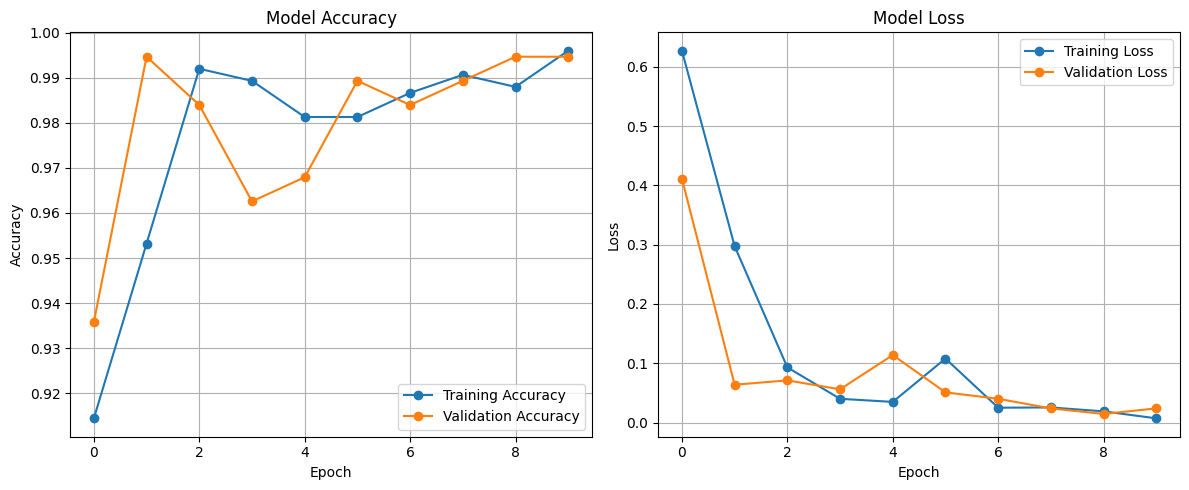

Graph Saved Successfully!


In [20]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

# ======================================================
# Plot Loss Graph
# ======================================================

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig("saved_model/training_history.png")

plt.show()

print("Graph Saved Successfully!")


## Try it on your own text

In [21]:
def predict_text(text, model=model, tokenizer=tokenizer, max_len=MAX_LENGTH):
    seq = tokenizer.texts_to_sequences([clean_text(text)])
    pad = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")
    prob = float(model.predict(pad, verbose=0)[0][0])
    label = "AI-generated" if prob > 0.5 else "Human-written"
    return label, {"ai_prob": prob, "human_prob": 1 - prob}

sample = "Paste any paragraph here to test the classifier."
print(predict_text(sample))


('AI-generated', {'ai_prob': 0.9995412826538086, 'human_prob': 0.00045871734619140625})


## Notes

- **Class imbalance is the main limitation.** Only 85 confirmed AI-generated examples exist; the human pool is capped at 10x that for training, and `class_weight` further compensates during training. Still, generalization to AI text styles not seen in training (different LLMs/topics) will be limited.
- `saved_model/model.keras`, `saved_model/tokenizer.pkl`, and `saved_model/training_history.png` are all saved to the Colab file system — download them from the file browser on the left, or add a `google.colab.files.download(...)` call if you want them to prompt a download automatically.
- To go further: try more AI-generated sources, tune `VOCAB_SIZE`/`MAX_LENGTH`/`EMBEDDING_DIM`, or compare against the transformer (DistilBERT) version for a stronger baseline.
